In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import scipy
import math

In [9]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class import ModularStrategy
from Strategies.Modular_strategy.strategy_class_new import ModularStrategy as NewStrategy

import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [19]:
def df_days_tag(df):
    unique_dates = df['timestamp'].dt.date.unique()
    
    # Create a dictionary to map unique dates to tags
    date_to_tag = {date: tag for tag, date in enumerate(unique_dates)}
    
    # Add a new column for the tags
    df['day'] = df['timestamp'].dt.date.map(date_to_tag)
    
    return df.copy()

In [12]:
df_data = pd.read_parquet(r"W:\data_factory\backtest_obt_deq1.parquet")
def clean_ba_dupl(df_input):
    df = df_input[['b_price', 'a_price', 'trd_price']].copy()
    df['b_price_lag'] = df['b_price'].shift(1)
    df['a_price_lag'] = df['a_price'].shift(1)
    df['mask'] = (
        (df['b_price_lag'] != df['b_price']) |
        (df['a_price_lag'] != df['a_price']) |
        (~df['trd_price'].isna())
    )
    return df['mask']

df_test = df_data.copy()
df_data = df_data[clean_ba_dupl(df_data)]
df_data = df_data.reset_index(names='timestamp')
df_data['ba_spread'] = (df_data['a_price'] - df_data['b_price']).round(2)
df_data.loc[df_data['trd_price'] > 0, 'trd_vol'] = 1

In [10]:
try:
    with open(get_curr_storage_path() + "martin/cache_r_0.35_0.4_0.12_60_2024-07-01_2024-11-11.pkl", "rb") as f:
        cached_r = pickle.load(f)
except EOFError:
    print("The file is empty or corrupted")
except FileNotFoundError:
    print("The file does not exist")

In [18]:
df_data['day']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
784035   NaN
784036   NaN
784037   NaN
784038   NaN
784039   NaN
Name: day, Length: 784040, dtype: float64

In [ ]:
data_columns = [
        'a_price_sparsity',
        'b_price_sparsity',
        'scaled_sparsity',
        'ba_volrat_30',
        'ba_volrat_00',
        '_far_level',
        'interval_int',
        'interval_pdiff',
        'p_movement_0.3',
        'ba_spread']

df_data = df_days_tag(df_data)
df_data.reset_index(names='index', inplace=True)
df_obt = df_data.copy()
df_data = df_data[pd.notna(df_data['trd_price'])]
df_data = df_data[df_data[data_columns].notnull().all(axis=1)]

In [11]:
cache_short = np.array([x['short'][1] for x in cached_r.values()])
cache_long = np.array([x['long'][1] for x in cached_r.values()])


In [189]:
X = df_data[data_columns].values
y = cache_long

In [ ]:
def_ret = cache_long.mean()

In [103]:
n = 100
curr_pnl = 2
tp = 0.55

In [57]:
100*def_ret

-16.615253312685873

In [ ]:
cache_short

numpy.ndarray

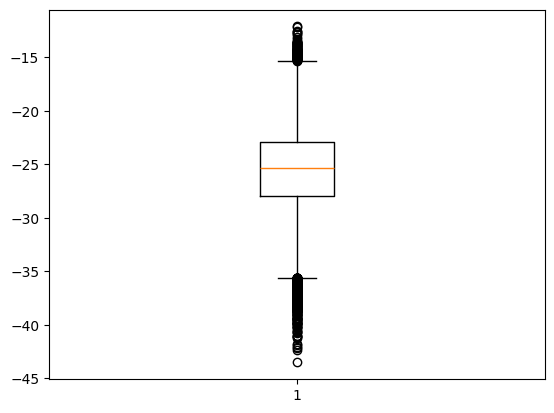

-16.429999999999996


In [12]:
results = []
for _ in range(100000):
    p = 100/len(cache_long)  # ≈ 0.01786
    random_entries = np.random.binomial(1, p, len(cache_long))
    results.append(cache_long[random_entries == 1].sum())

import matplotlib.pyplot as plt
plt.boxplot(results)
plt.show()
print(pd.Series(results).quantile(0.995))

In [269]:
cache_short[random_entries == 1].sum()

-178.98000000000002

In [266]:
random_entries.shape

(56000,)

In [ ]:
cache_p = np.random.rand

In [105]:
def custom_loss(n, curr_pnl, tp, def_ret):
    optimal_pnl = n * tp * 0.5 + n * def_ret
    baseline_pnl = n * def_ret
    return (optimal_pnl - curr_pnl) / (optimal_pnl - baseline_pnl)

In [106]:
eq = lambda X_s, c_s, def_ret: def_ret + X_s * c_s

In [190]:
X = torch.tensor(X[:1000]).float()
y = torch.tensor(y[:1000])

In [232]:
cache_short

array([ 0.49,  0.51,  0.51, ..., -1.04, -1.04, -1.04])

In [187]:
0.5 * (np.sum(cache_long[X_mask])/cache_short[X_mask].shape[0]+np.sum(cache_short[X_mask])/cache_short[X_mask].shape[0])

-0.11758652575957729

In [221]:
def custom_loss_gradient(X, theta, y, tp, def_ret):
    """
    Compute the gradient of the custom loss function w.r.t. theta.
    
    Parameters:
        X (ndarray): Design matrix (m samples x n features)
        theta (ndarray): Model weights (n features,)
        y (ndarray): Actual target values (m samples,)
        tp (float): Target profit per trade
        def_ret (float): Baseline return per trade
    
    Returns:
        grad (ndarray): Gradient of loss w.r.t. theta
    """
    epsilon = torch.tensor(1e-8)  # Small constant to prevent instability
    # Predictions: hat_y = X @ theta
    hat_y = torch.clip(X @ theta, -1e6, 1e6)  # Shape: (m,)
    
    # Compute optimal_pnl and baseline_pnl (constants)
    n = y.shape[0]  # Number of samples/trades
    optimal_pnl = n * (tp * 0.5 + def_ret)
    baseline_pnl = n * def_ret
    
    # Loss denominator: optimal_pnl - baseline_pnl
    denom = torch.max(optimal_pnl - baseline_pnl, epsilon)
    
    # Gradient of loss w.r.t. curr_pnl
    dL_dcurr_pnl = -1 / denom  # Scalar
    
    # Gradient of curr_pnl w.r.t. theta: X.T @ error
    error = torch.clip(hat_y - y, -1e6, 1e6).float()  # Shape: (m,)
    dcurr_pnl_dtheta = X.T @ error  # Shape: (n,)
    
    # Combine gradients using chain rule
    grad = dL_dcurr_pnl * dcurr_pnl_dtheta
    
    return grad

In [192]:
theta = np.random.randn(X.shape[1])  # Initial weights

In [ ]:
X = torch.hstack([torch.ones(X.shape[0], 1), X])

tensor([[ 0.3300,  0.0500,  0.9498,  ...,  0.0000,  1.0000,  0.6900],
        [ 0.1500,  0.1100,  0.2319,  ...,  0.0000,  1.0000,  0.6000],
        [ 0.1400,  0.1200,  0.1469,  ...,  0.0000,  1.0000,  0.3800],
        ...,
        [ 0.1100,  0.1100,  0.0000,  ..., -0.1000,  0.6400,  0.0900],
        [ 0.1100,  0.1100,  0.0000,  ...,  0.0000,  0.6400,  0.0900],
        [ 0.0200,  0.1000, -0.9307,  ...,  0.0000,  0.5625,  0.0600]])

In [224]:
X = torch.hstack([torch.ones(X.shape[0], 1), X])
theta = torch.zeros(X.shape[1])  # Initial weights
tp = torch.tensor(0.55)
def_ret = torch.tensor(def_ret)
grad = custom_loss_gradient(X, theta, y, tp, def_ret)

C:\Users\scasny\AppData\Local\Temp\ipykernel_11668\3556930108.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  def_ret = torch.tensor(def_ret)


In [225]:
grad

tensor([-0.2804, -0.0246, -0.0723,  0.1993,  0.1583,  0.0574, -0.1992, -0.7107,
         0.0053, -0.1623, -0.0773])

In [ ]:
theta = torch.tensor([0.])

In [229]:
(X @ theta)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [231]:
y.shape

torch.Size([1000])

In [ ]:
data_columns = 

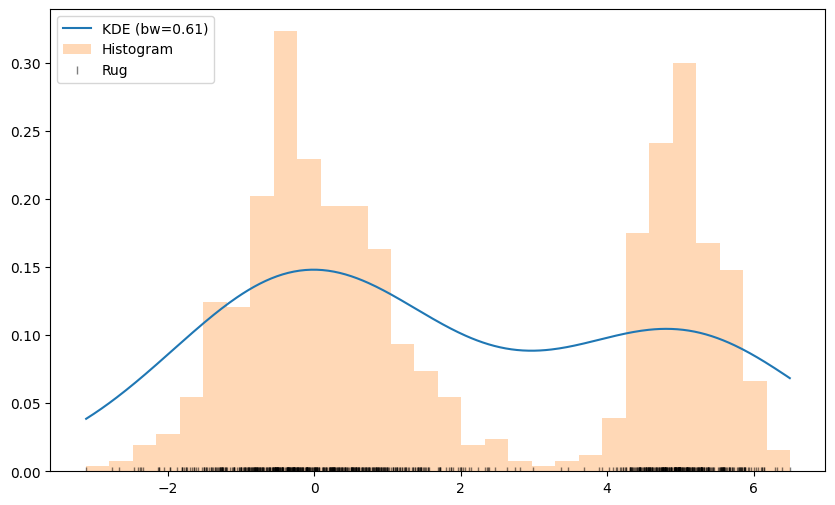

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def kde_arziv_style(data, bw_method='experimental', cut=3, cumulative=False, 
                    rug=False, grid_points=512, ax=None):
    """
    ArviZ-style KDE implementation without ArviZ dependency
    
    Parameters mirror ArviZ's plot_kde defaults:
    - Experimental bandwidth selection
    - Boundary-aware estimation
    - Rug plot capability
    """
    # Calculate bandwidth
    if bw_method == 'experimental':
        # ArviZ's experimental bandwidth formula (simplified)
        n = len(data)
        iqr = stats.iqr(data)
        std = np.std(data, ddof=1)
        sigma = min(std, iqr/1.34) if iqr > 0 else std
        bw = 0.9 * sigma * n**-0.2  # Modified Silverman's rule
    else:
        bw = bw_method

    # Create grid boundaries
    data_min = data.min() - cut*bw
    data_max = data.max() + cut*bw
    grid = np.linspace(data_min, data_max, grid_points)

    # Compute KDE
    kernel = stats.gaussian_kde(data, bw_method=bw)
    pdf = kernel(grid)

    # Truncate at data boundaries (ArviZ style)
    mask = (grid >= data.min()) & (grid <= data.max())
    grid = grid[mask]
    pdf = pdf[mask]
    
    # Normalize after truncation
    pdf /= np.trapz(pdf, grid)

    # Create plot if requested
    if ax is not None:
        ax.plot(grid, pdf, label='KDE')
        if rug:
            ax.plot(data, np.zeros_like(data), '|', color='k', alpha=0.5)
        if cumulative:
            cdf = np.cumsum(pdf) * (grid[1] - grid[0])
            ax.plot(grid, cdf/cdf[-1], label='CDF')
    
    return grid, pdf, bw

# Usage example
if __name__ == "__main__":
    # Generate sample data (Gaussian mixture)
    data = np.concatenate([
        np.random.normal(0, 1, 500),
        np.random.normal(5, 0.5, 300)
    ])
    
    # Compute KDE
    grid, pdf, bw = kde_arziv_style(data, rug=True)
    
    # Plot results
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(grid, pdf, label=f'KDE (bw={bw:.2f})')
    ax.hist(data, bins=30, density=True, alpha=0.3, label='Histogram')
    ax.plot(data, np.zeros_like(data), '|', color='k', alpha=0.5, label='Rug')
    ax.legend()
    plt.show()


In [3]:
import numpy as np
from scipy import stats

def kde_quantiles(data, lower_quantile=0.05, upper_quantile=0.95, 
                 bw_method='experimental', grid_points=1024, cut=3):
    """
    Calculate quantile boundaries using KDE estimation
    
    Parameters:
    data : array-like - Input data
    lower_quantile : float (0-1) - Lower boundary quantile
    upper_quantile : float (0-1) - Upper boundary quantile
    bw_method : str/float - Bandwidth method ('experimental', 'scott', 'silverman' or number)
    grid_points : int - Number of grid points for KDE evaluation
    cut : int - Number of bandwidths to extend beyond data limits
    
    Returns:
    tuple - (lower_bound, upper_bound)
    """
    # Calculate bandwidth
    if bw_method == 'experimental':
        n = len(data)
        iqr = stats.iqr(data)
        std = np.std(data, ddof=1)
        sigma = min(std, iqr/1.34) if iqr > 0 else std
        bw = 0.9 * sigma * n**-0.2
    else:
        bw = bw_method
    
    # Create KDE grid
    kde = stats.gaussian_kde(data, bw_method=bw)
    data_min, data_max = data.min(), data.max()
    grid = np.linspace(data_min - cut*bw, data_max + cut*bw, grid_points)
    
    # Calculate PDF and CDF
    pdf = kde(grid)
    cdf = np.cumsum(pdf)
    cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min())  # Normalize to [0,1]
    
    # Find quantile boundaries
    lower_bound = np.interp(lower_quantile, cdf, grid)
    upper_bound = np.interp(upper_quantile, cdf, grid)
    
    return (lower_bound, upper_bound)

# Usage example
if __name__ == "__main__":
    # Generate sample data (normal distribution)
    data = np.random.normal(10, 2, 1000)
    
    # Get 5% and 95% boundaries
    lower, upper = kde_quantiles(data, 0.05, 0.95)
    print(f"5%-95% KDE boundaries: ({lower:.2f}, {upper:.2f})")
    
    # Compare with numpy quantiles
    np_lower = np.quantile(data, 0.05)
    np_upper = np.quantile(data, 0.95)
    print(f"Direct data quantiles: ({np_lower:.2f}, {np_upper:.2f})")


5%-95% KDE boundaries: (6.39, 13.54)
Direct data quantiles: (6.70, 13.18)


In [4]:
np.min(data)

3.049375212224387

In [16]:
kde = stats.gaussian_kde(data)

In [17]:
grid = np.linspace(data.min(), data.max(), 1024)
pdf = kde(grid)

In [13]:
stats.iqr(data, rng=(5, 95))

6.4817106253846415

In [23]:
np.quantile(pdf, (0.05, 0.95))

array([0.00295968, 0.19950445])

In [26]:
cdf = np.cumsum(pdf)
cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min())  # Normalize to [0,1]

In [28]:
# Find quantile boundaries
lower_bound = np.interp(0.05, cdf, grid)
upper_bound = np.interp(0.95, cdf, grid)
lower_bound, upper_bound

(6.5892831194183765, 13.283749504262383)

array([ 3.04937521,  3.06165383,  3.07393244, ..., 15.5858406 ,
       15.59811921, 15.61039783])